In [9]:
import pandas as pd
from pathlib import Path
import numpy as np

In [32]:
SAMPLE_FILE = Path(f"C:/Users/Thinkerman/gridcast-pjm-load-forecasting/data/raw/sample/PJME_hourly.csv")

df=pd.read_csv(SAMPLE_FILE)
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [44]:
print ("\n=== types =====")
print(df.dtypes)

print ("\n === info ====")
print (df.info())



# check the granularity of the time
df = df.astype({"Datetime":"datetime64[s]"})
df=df.sort_values(['Datetime'])
df = df.reset_index(drop=True)
time_distance = df["Datetime"].diff()
# time_distance =  df["Datetime"]-df["Datetime"].shift(1)

print("\n===max time distance =====")
print (time_distance.max())

print("\n===mean time distance =====")
print (time_distance.mean())

print("\n===min time distance =====")
print (time_distance.min())




=== types =====
Datetime    datetime64[s]
PJME_MW           float64
dtype: object

 === info ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype        
---  ------    --------------   -----        
 0   Datetime  145366 non-null  datetime64[s]
 1   PJME_MW   145366 non-null  float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 2.2 MB
None

===max time distance =====
0 days 02:00:00

===mean time distance =====
0 days 01:00:00

===min time distance =====
0 days 00:00:00


In [46]:
# is the time delta mostly 1 hour?

in_hour_time_distance = time_distance/ pd.Timedelta(hours=1)
#bar would not be informative
print ( np.histogram( in_hour_time_distance.dropna().values ))

(array([     4,      0,      0,      0,      0, 145331,      0,      0,
            0,     30]), array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]))


it shows we have 4 exact timestamp consequently. 
and 30 time stamp have 2 hour distance with the previous record (delay)

In [47]:
# are there duplicate timestamps?

df[ df['Datetime'].duplicated(False)]

,Datetime,PJME_MW
112487,2014-11-02 02:00:00,23755.0
112488,2014-11-02 02:00:00,22935.0
121223,2015-11-01 02:00:00,21567.0
121224,2015-11-01 02:00:00,21171.0
130127,2016-11-06 02:00:00,20795.0
130128,2016-11-06 02:00:00,21692.0
138863,2017-11-05 02:00:00,21236.0
138864,2017-11-05 02:00:00,20666.0


some duplicated times but! is it a jump or I mean does it skip the true one ( which we can compensate the true one) or just a data glitch.
we will figure out later

In [48]:
# what’s min/max date?

print (" \n === last DateTime =====")
print(df["Datetime"].max())

print (" \n === First DateTime =====")
print((df["Datetime"].min()))

 
 === last DateTime =====
2018-08-03 00:00:00
 
 === First DateTime =====
2002-01-01 01:00:00


<Axes: >

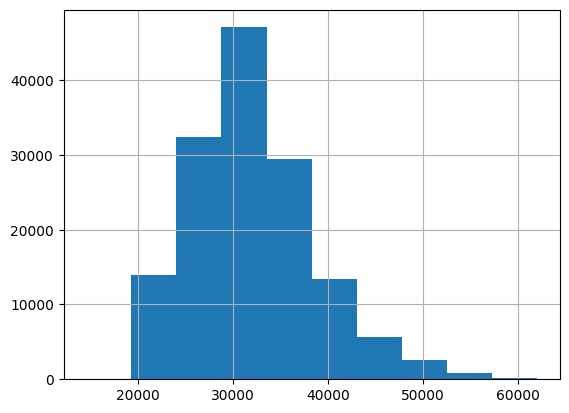

In [42]:
# what’s min/max/mean load?

df["PJME_MW"].hist(bins=10)


Well.. this is obvious that most of the power consumption values are between 25000 and 35000